In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
pd.__version__

'2.2.2'

In [38]:
sns.__version__

'0.13.2'

In [44]:
import matplotlib
print(matplotlib.__version__)


3.9.1


In [2]:
!ls

1-RBPBench.ipynb
1-RBPBench-rbp-deg-specific.ipynb
2-parse_rbpbench_output_positive-negative-psi-deg_specific.ipynb
2-parse_rbpbench_output_positive-negative-psi.ipynb
3-parse_rbp_output-deg_specific.ipynb
3-parse_rbp_output.ipynb
4-rbp-plot-deg-specific.ipynb
enriched_motif_DASE_negative_psi_intellectual_disability.csv
enriched_motif_DASE_positive_psi_intellectual_disability.csv
final_motif_with_position.xlsx
intellectual_disability_PCB153-vs-CTR_ASE_specific_coordinates_enmo
intellectual_disability_PCB153-vs-CTR_ASE_specific_coordinates_search
negative_PSI_events.png
nested_pie_chart.png
PCB153-vs-CTR_ASE_specific_coordinates_enmo
PCB153-vs-CTR_ASE_specific_coordinates_search
positive_PSI_events.png
RBP_BENCH_negative_PSI
RBP_BENCH_positive_PSI
RBP_DEG_specific
RBP_DEG_specific_enriched_motif_DASE_negative_psi_intellectual_disability.csv
RBP_DEG_specific_enriched_motif_DASE_positive_psi_intellectual_disability.csv
RBP_DEG_specific_final_motif_with_position.xlsx


In [3]:
df=pd.read_excel("RBP_DEG_specific_final_motif_with_position.xlsx")
df.head()

,rbp_id,motif_id,expanded_sequence,gen_s,gen_e,region_s,region_e,region_len,uniq_count,DASE_sequence,Class,GeneID,geneSymbol,FDR,IncLevelDifference,DE-NOVO,motif_position
0,CELF2,CELF2_1,chr1:75728150-75728738(+),75728490,75728496,340,346,588,2,chr1:75728150-75728738(+),MXE,ENSG00000117054,ACADM,0.012140,0.229,False,downstream
1,CELF2,CELF2_1,chr1:75728150-75728738(+),75728539,75728545,389,395,588,2,chr1:75728150-75728738(+),MXE,ENSG00000117054,ACADM,0.012140,0.229,False,downstream
2,CELF2,CELF2_1,chr11:68179881-68180450(-),68180060,68180066,385,391,569,2,chr11:68179881-68180450(-),MXE,ENSG00000110066,KMT5B,0.008150,0.127,False,downstream
3,CELF2,CELF2_1,chr11:68179609-68180450(-),68180060,68180066,385,391,841,2,chr11:68179609-68180450(-),MXE,ENSG00000110066,KMT5B,0.003254,0.217,True,exon
4,CELF2,CELF2_1,chr8:74351071-74351716(+),74351081,74351087,10,16,645,1,chr8:74351071-74351716(+),A5SS,ENSG00000104381,GDAP1,0.000716,0.375,False,upstream


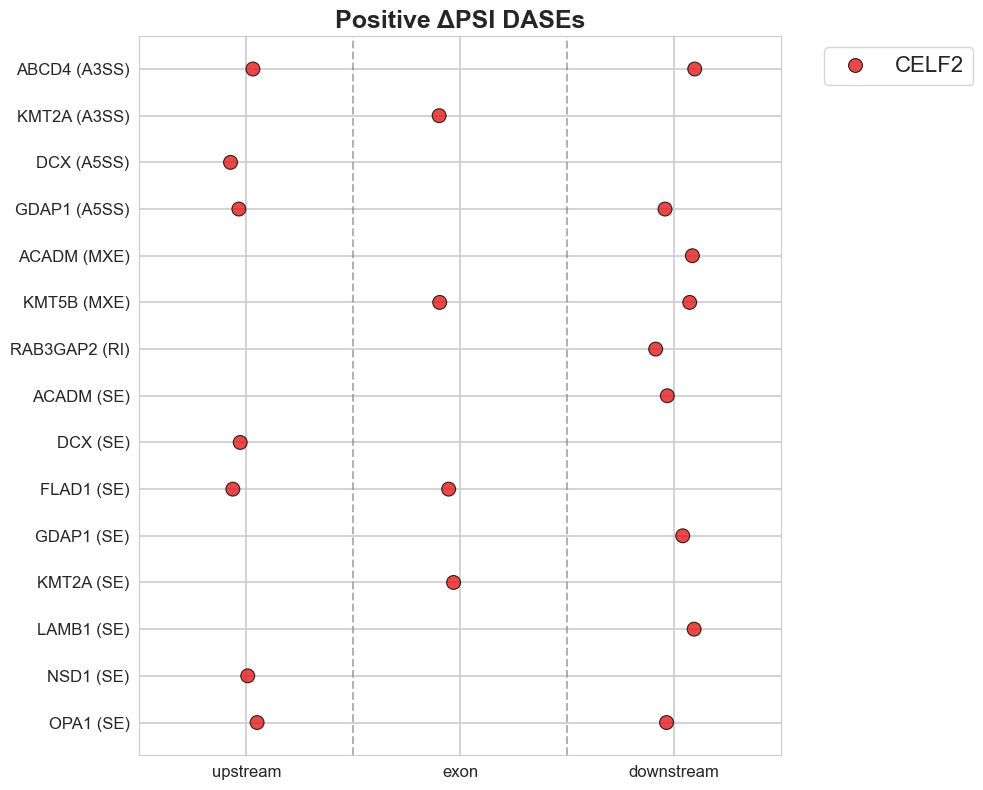

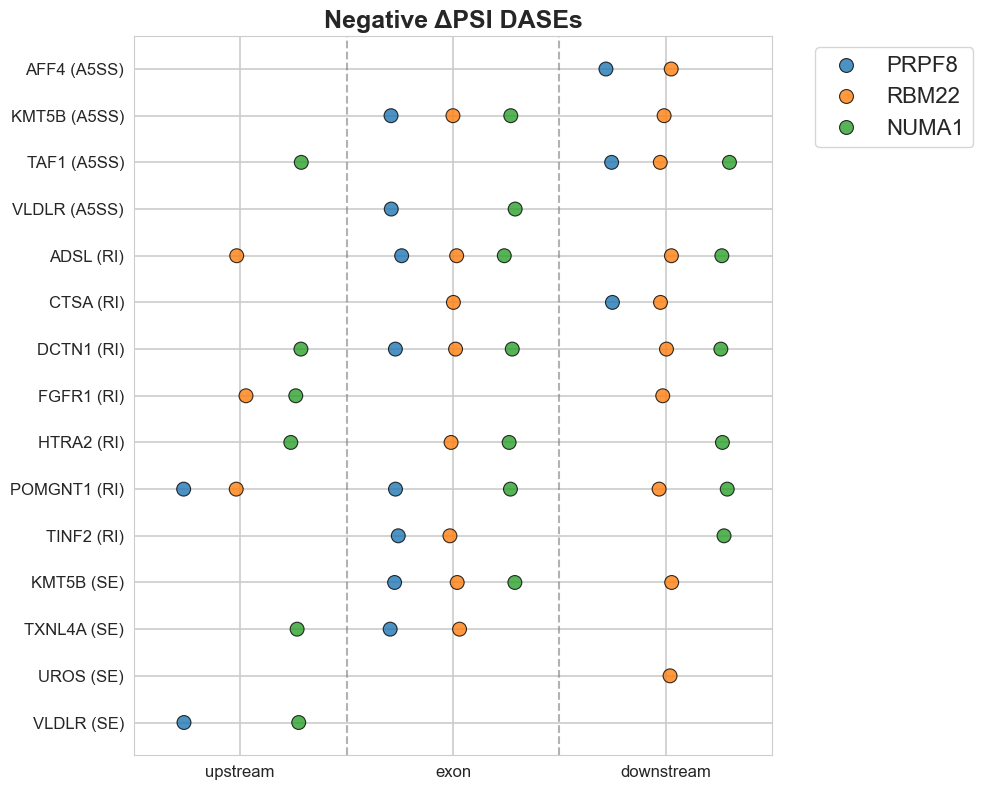

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Example: Make sure your DataFrame 'df' exists
# df = pd.read_csv("your_data.csv")  # Uncomment and adjust if needed

# Order motif positions
df['motif_position'] = pd.Categorical(
    df['motif_position'],
    categories=['upstream', 'exon', 'downstream'],
    ordered=True
)
df_pos = df[df['IncLevelDifference'] > 0]
df_neg = df[df['IncLevelDifference'] < 0]
# Sort by Class (event type) and then geneSymbol
df_pos = df_pos.sort_values(by=['Class', 'geneSymbol'])
df_neg = df_neg.sort_values(by=['Class', 'geneSymbol'])
# Create pretty y-axis label: GeneSymbol (Class)
df_pos['GeneClass'] = df_pos['geneSymbol'] + " (" + df_pos['Class'] + ")"
df_neg['GeneClass'] = df_neg['geneSymbol'] + " (" + df_neg['Class'] + ")"
# Make categories unique and preserve order to avoid Categorical error
unique_labels_pos = df_pos['GeneClass'].drop_duplicates()
unique_labels_neg = df_neg['GeneClass'].drop_duplicates()
df_pos['GeneClass'] = pd.Categorical(df_pos['GeneClass'], categories=unique_labels_pos, ordered=True)
df_neg['GeneClass'] = pd.Categorical(df_neg['GeneClass'], categories=unique_labels_neg, ordered=True)
df_pos=df_pos[['rbp_id','motif_position', 'GeneClass']].drop_duplicates()
df_neg=df_neg[['rbp_id','motif_position', 'GeneClass']].drop_duplicates()
def make_plot(data, title, filename,colori):
    plt.figure(figsize=(10, 8))
    ax = sns.stripplot(
        data=data,
        x='motif_position',
        y='GeneClass',
        hue='rbp_id',
        dodge=True,
        jitter=True,
        size=10,
        palette=colori,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.8
    )

    # Strong vertical and horizontal grid lines
    ax.xaxis.grid(True, which='major', linewidth=1.2)  # vertical
    ax.yaxis.grid(True, which='major', linewidth=1.2)  # horizontal

    # Add vertical separators between motif categories
    for i in range(len(data['motif_position'].cat.categories) - 1):
        ax.axvline(i + 0.5, color='gray', linestyle='--', alpha=0.6)

    # Labels and title
    plt.title(title, fontsize=18, weight='bold')
    plt.xlabel("")
    plt.ylabel("")

    # Ticks
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=16)
    plt.tight_layout()

    # Save figure
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


# Positive PSI
make_plot(df_pos, "Positive ΔPSI DASEs", "positive_PSI_events.png",'Set1')

# Negative PSI
make_plot(df_neg, "Negative ΔPSI DASEs", "negative_PSI_events.png",'tab10')


In [19]:
df['motif_position'] = pd.Categorical(
    df['motif_position'],
    categories=['upstream', 'exon', 'downstream'],
    ordered=True
)
df_pos = df[df['IncLevelDifference'] > 0]
df_neg = df[df['IncLevelDifference'] < 0]


In [20]:
df_neg.columns

Index(['rbp_id', 'motif_id', 'expanded_sequence', 'gen_s', 'gen_e', 'region_s',
       'region_e', 'region_len', 'uniq_count', 'DASE_sequence', 'Class',
       'GeneID', 'geneSymbol', 'FDR', 'IncLevelDifference', 'DE-NOVO',
       'motif_position'],
      dtype='object')

In [21]:
df_neg=df_neg[['rbp_id','DASE_sequence','Class','geneSymbol','motif_position']].drop_duplicates()
df_pos=df_pos[['rbp_id','DASE_sequence','Class','geneSymbol','motif_position']].drop_duplicates()

In [22]:
# Append together
df_all = pd.concat([df_neg, df_pos], ignore_index=True)

# Optional: remove duplicates across both
df_all = df_all.drop_duplicates()
df_all

,rbp_id,DASE_sequence,Class,geneSymbol,motif_position
0,NUMA1,chr11:68179219-68180381(-),A5SS,KMT5B,exon
1,NUMA1,chrX:71422989-71423514(+),A5SS,TAF1,upstream
2,NUMA1,chrX:71422989-71423514(+),A5SS,TAF1,downstream
3,NUMA1,chr9:2647342-2648597(+),A5SS,VLDLR,exon
4,NUMA1,chr14:24240080-24240668(-),RI,TINF2,downstream
...,...,...,...,...,...
77,CELF2,chr5:177237986-177238757(+),SE,NSD1,upstream
78,CELF2,chr7:107958998-107959730(-),SE,LAMB1,downstream
79,CELF2,chr11:118471411-118472235(+),SE,KMT2A,exon
80,CELF2,chrX:111312388-111312986(-),SE,DCX,upstream


In [23]:
level2_counts

rbp_id  motif_position
PRPF8   downstream         3
        exon              10
        upstream           2
RBM22   downstream        12
        exon              10
        upstream           3
NUMA1   downstream         6
        exon               9
        upstream           6
CELF2   downstream         9
        exon               4
        upstream           8
dtype: int64

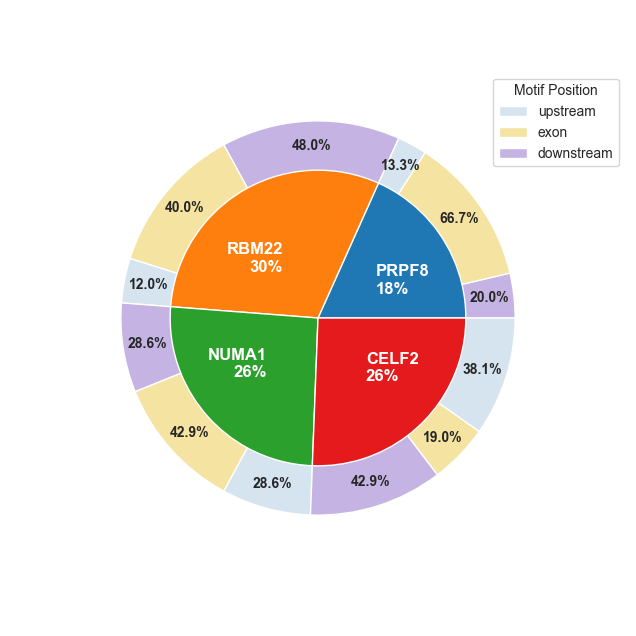

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # for legend

# --- RBP and motif ordering ---
rbp_order = ['PRPF8','RBM22','NUMA1','CELF2']
motif_order = ['downstream','exon', 'upstream']

# --- Count preparation ---
level1_counts = df_all['rbp_id'].value_counts().reindex(rbp_order)
level2_counts = (
    df_all.groupby(['rbp_id','motif_position'], observed=True)
    .size()
    .reindex(pd.MultiIndex.from_product([rbp_order, motif_order],
                                        names=['rbp_id','motif_position']))
    .fillna(0)
)

# --- Color definitions ---
rbp_colors = {
    'PRPF8': '#1f77b4',
    'RBM22': '#ff7f0e',
    'NUMA1': '#2ca02c',
    'CELF2': '#e41a1c'
}

motif_colors = {
    'upstream':   '#D6E4F0',  # pastel powder blue
    'exon':       '#F4E3A1',  # pastel yellow
    'downstream': '#C5B4E3'   # pastel violet
}




# --- Prepare outer ring data ---
outer_sizes = []
outer_colors = []
outer_labels = []

for rbp in rbp_order:
    total = level1_counts[rbp]
    for motif in motif_order:
        count = level2_counts.loc[(rbp, motif)]
        if count > 0:
            outer_sizes.append(count)
            outer_colors.append(motif_colors[motif])
            pct = count / total * 100
            outer_labels.append(f"{pct:.1f}%")

# --- Plot nested pie chart ---
fig, ax = plt.subplots(figsize=(8,8))

# --- Prepare inner labels with percentages ---
total_all = level1_counts.sum()
inner_labels = [
    f"{rbp}\n{(level1_counts[rbp]/total_all*100):.0f}%"
    for rbp in rbp_order
]

# Inner pie
ax.pie(level1_counts,
       labels=inner_labels,
       colors=[rbp_colors[r] for r in rbp_order],
       radius=0.7,
       wedgeprops=dict(width=0.7, edgecolor='white'),
       labeldistance=0.4,
       textprops=dict(color="white", fontsize=12, weight='bold'))


# Outer pie
outer_wedges, _ = ax.pie(outer_sizes,
       labels=['']*len(outer_sizes),
       colors=outer_colors,
       radius=0.8,
       wedgeprops=dict(width=0.2, edgecolor='white'))

# --- Place horizontal labels centered in each wedge ---
for wedge, label in zip(outer_wedges, outer_labels):
    theta = (wedge.theta2 + wedge.theta1) / 2
    r = 0.8 - 0.1
    x = r * np.cos(np.deg2rad(theta))
    y = r * np.sin(np.deg2rad(theta))
    
    ax.text(x, y, label, rotation=0, ha='center', va='center',
            fontsize=10, weight='bold')

# --- Add legend for outer ring ---
legend_handles = [Patch(facecolor=color, edgecolor='white', label=motif) 
                  for motif, color in motif_colors.items()]
ax.legend(handles=legend_handles, title="Motif Position",
          loc="upper right", bbox_to_anchor=(1, 0.9))

ax.set(aspect="equal")
# --- Save figure at 300 dpi ---
plt.savefig("nested_pie_chart.png", dpi=300, bbox_inches='tight')

# Then show the figure
plt.show()

